In [35]:
!pip install japanize-matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 01 — EDA: 木材近赤外スペクトルの探索的データ分析

目的変数（含水率）と近赤外スペクトルの基本的な特性を把握する。

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from src.utils import load_data, parse_spectra
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'

train_df, test_df = load_data()
print('train:', train_df.shape, '  test:', test_df.shape)

train: (1322, 1559)   test: (550, 1558)


In [37]:
train_meta, y_train, X_train, wn = parse_spectra(train_df)
test_meta,  _,       X_test,  _  = parse_spectra(test_df)

print('wavenumber range:', wn.max(), '—', wn.min(), 'cm⁻¹')
print('n_wavelengths:', len(wn))
print('moisture range:', y_train.min(), '—', y_train.max(), '%')
train_meta.head(3)

wavenumber range: 9993.76781 — 3999.82139 cm⁻¹
n_wavelengths: 1555
moisture range: 0.840336134 — 298.5815603 %


,sample number,species number,樹種
0,1,1,イチョウ
1,2,1,イチョウ
2,3,1,イチョウ


## 1. 樹種分布

['species number', '樹種']


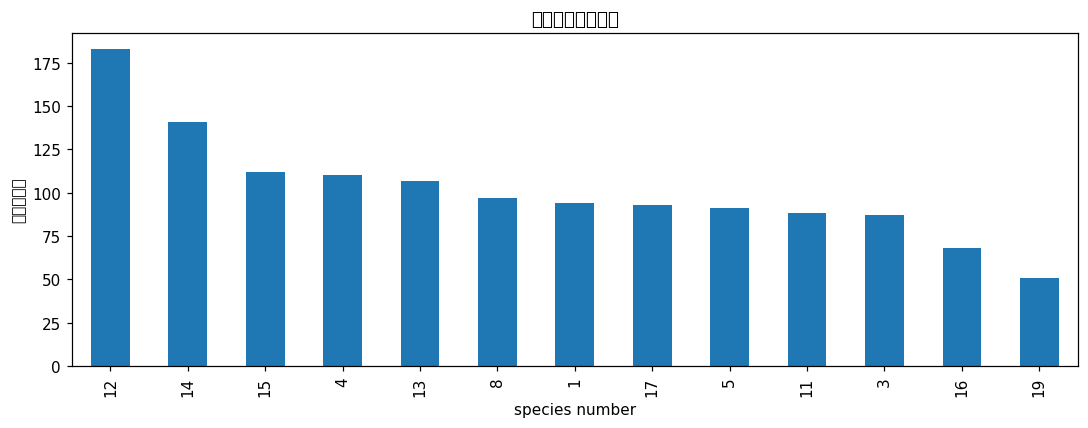

species number
12    183
14    141
15    112
4     110
13    107
8      97
1      94
17     93
5      91
11     88
3      87
16     68
19     51
Name: count, dtype: int64


In [38]:
species_col = [c for c in train_meta.columns if '樹種' in c or 'species' in c.lower()]
print(species_col)

counts = train_meta[species_col[0]].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
counts.plot.bar(ax=ax)
ax.set_title('測定数（樹種別）')
ax.set_ylabel('サンプル数')
plt.tight_layout()
plt.show()
print(counts)

## 2. 含水率の分布

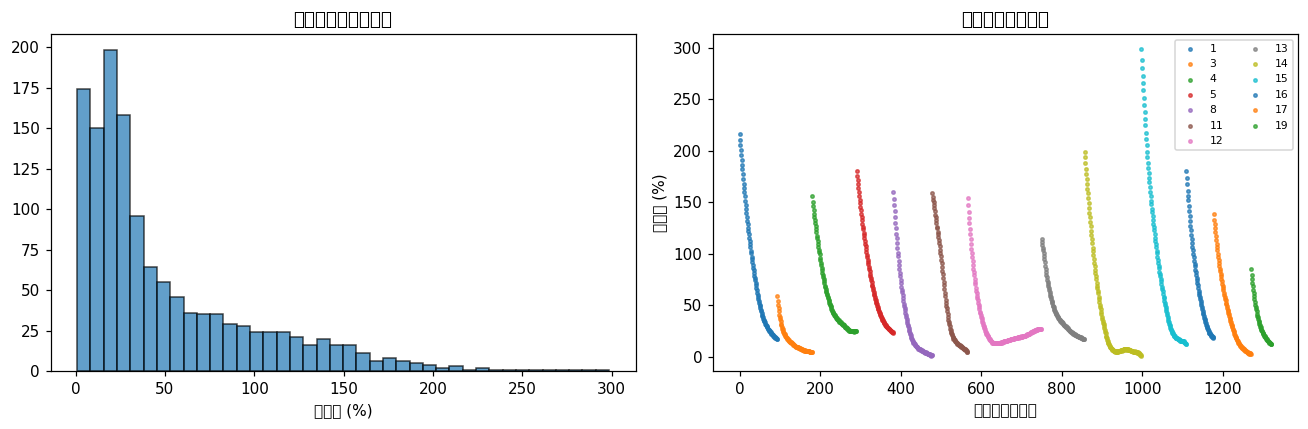

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=40, edgecolor='k', alpha=0.7)
axes[0].set_xlabel('含水率 (%)')
axes[0].set_title('含水率ヒストグラム')

species_name = train_meta[species_col[0]].values
unique_species = np.unique(species_name)
for sp in unique_species:
    mask = species_name == sp
    axes[1].scatter(np.where(mask)[0], y_train.values[mask], s=5, label=sp, alpha=0.7)
axes[1].set_xlabel('行インデックス')
axes[1].set_ylabel('含水率 (%)')
axes[1].set_title('含水率（樹種別）')
axes[1].legend(fontsize=7, ncol=2, loc='upper right')

plt.tight_layout()
plt.show()

## 3. 生スペクトルの可視化

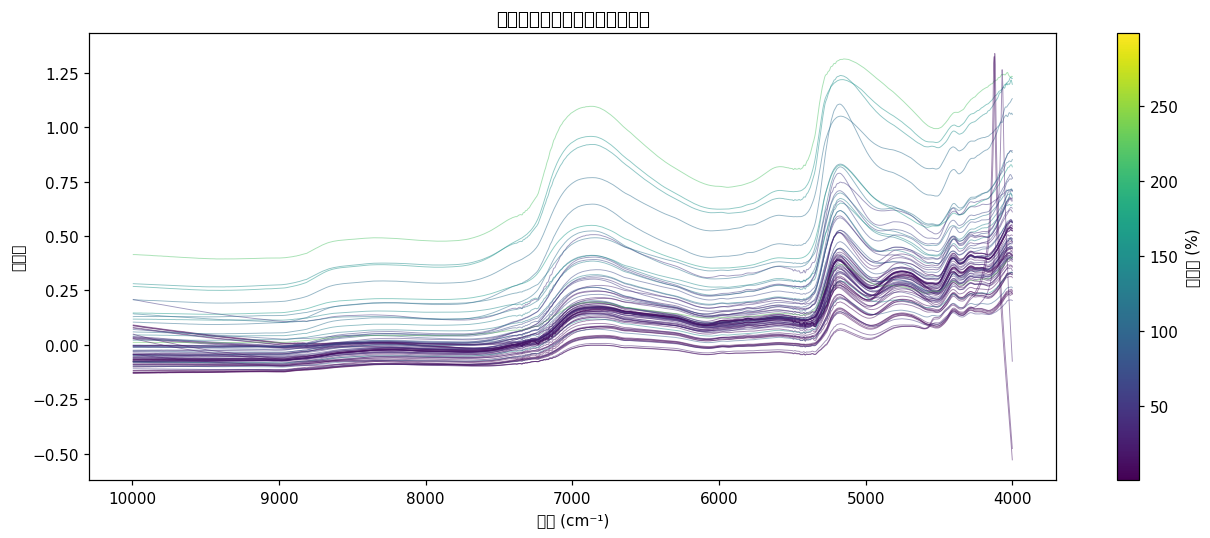

In [40]:
# 含水率でカラーマップ
y_norm = (y_train - y_train.min()) / (y_train.max() - y_train.min())
colors = cm.viridis(y_norm)

fig, ax = plt.subplots(figsize=(12, 5))
for i in range(0, len(X_train), max(1, len(X_train)//80)):
    ax.plot(wn, X_train[i], color=colors[i], alpha=0.5, linewidth=0.6)

sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(y_train.min(), y_train.max()))
plt.colorbar(sm, ax=ax, label='含水率 (%)')
ax.set_xlabel('波数 (cm⁻¹)')
ax.set_ylabel('吸光度')
ax.set_title('生スペクトル（含水率カラー）')
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 4. 波数ごとの含水率との相関

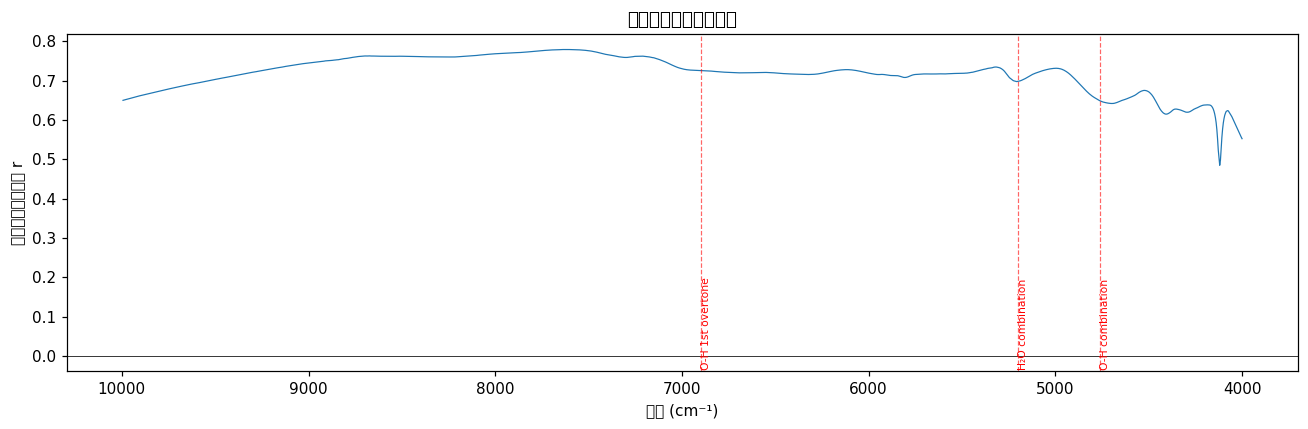

相関上位5波数 (cm⁻¹):
  7617.8 cm⁻¹  r=0.7791
  7621.6 cm⁻¹  r=0.7791
  7613.9 cm⁻¹  r=0.7791
  7625.5 cm⁻¹  r=0.7790
  7610.1 cm⁻¹  r=0.7790


In [41]:
corr = np.array([np.corrcoef(X_train[:, i], y_train)[0, 1] for i in range(X_train.shape[1])])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wn, corr, linewidth=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('波数 (cm⁻¹)')
ax.set_ylabel('ピアソン相関係数 r')
ax.set_title('各波数と含水率の相関')
ax.invert_xaxis()

# 水の主要吸収帯をアノテーション
for band, label in [(6900, 'O-H 1st overtone'), (5200, 'H₂O combination'), (4760, 'O-H combination')]:
    ax.axvline(band, color='r', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(band, ax.get_ylim()[0]*0.9, label, fontsize=7, rotation=90, color='r', va='bottom')

plt.tight_layout()
plt.show()

top5_idx = np.argsort(np.abs(corr))[-5:][::-1]
print('相関上位5波数 (cm⁻¹):')
for idx in top5_idx:
    print(f'  {wn[idx]:.1f} cm⁻¹  r={corr[idx]:.4f}')

## 5. 樹種別スペクトル平均

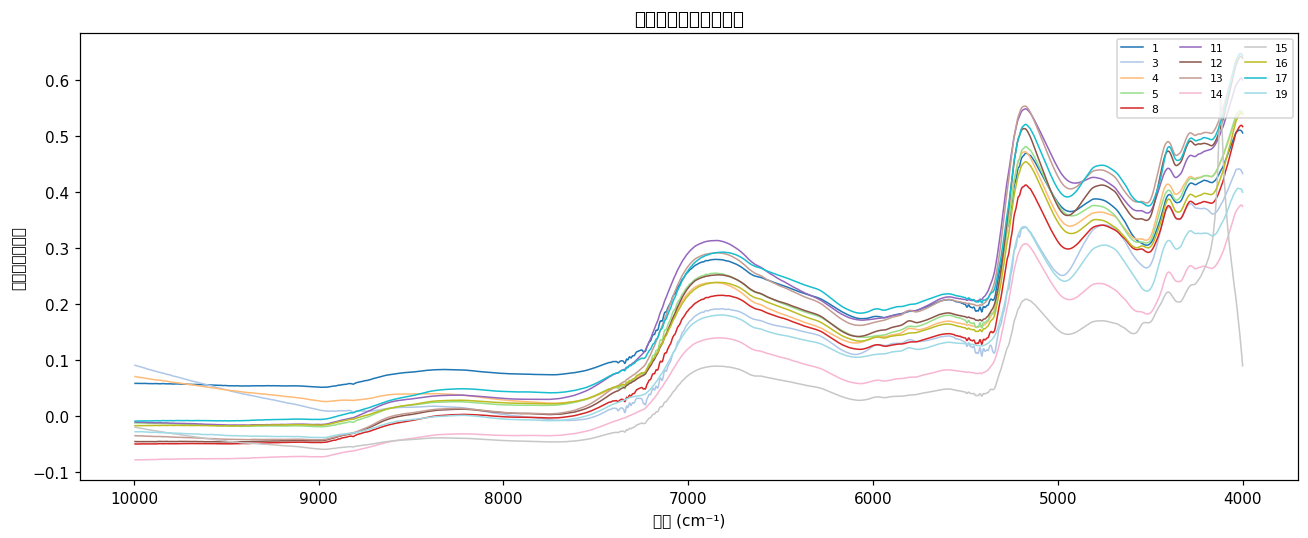

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))
palette = plt.cm.tab20(np.linspace(0, 1, len(unique_species)))
for sp, color in zip(unique_species, palette):
    mask = species_name == sp
    mean_spec = X_train[mask].mean(axis=0)
    ax.plot(wn, mean_spec, label=sp, color=color, linewidth=1.0)

ax.set_xlabel('波数 (cm⁻¹)')
ax.set_ylabel('吸光度（平均）')
ax.set_title('樹種別平均スペクトル')
ax.legend(fontsize=7, ncol=3, loc='upper right')
ax.invert_xaxis()
plt.tight_layout()
plt.show()